## 2/19 ef calibration - OP9500_photon

ef_freq =  

ef_pi_amp = 0.875


T1 = 20e-6

In [82]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

import sklearn
from sklearn.decomposition import PCA

In [83]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [3]:
def Rabi(delay, amp, phi0, detun, const):
    return - amp * np.cos(2*np.pi*detun*delay+phi0) + const

amp

In [85]:
header = "D:/K_sunada/result/CDK174_test"

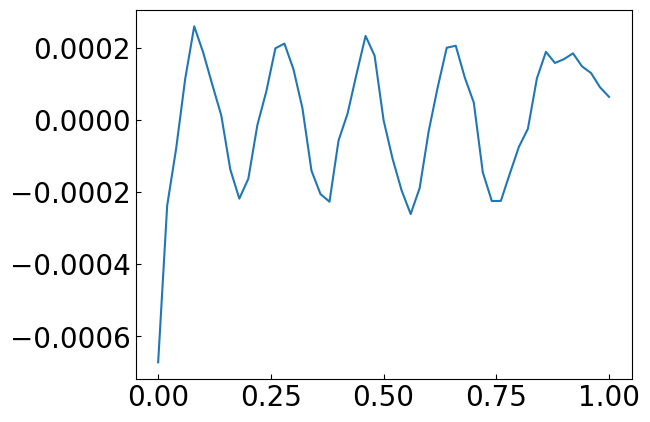

In [33]:

ef = "/2025-02-17/2025-02-17T161142_7096d1df-d0_ef_pi_amp"
dd_ef = datadict_from_hdf5(header + ef +"/data")

Rabi_ef = dd_ef['s11']['values']
amp_ef = dd_ef['amplitude']['values']
I = (Rabi_ef.real)
Q = (Rabi_ef.imag)
PCAef = PCA_transform(I, Q)

y = PCAef[0]
x = amp_ef
plt.plot(x, y)
plt.show()

In [36]:
par_ini= {'amp': 0.0002,'phi0':0,'detun':1/0.2,'const':0}
par_min = {'amp': 0,'phi0':-2*np.pi,'detun':-np.inf,'const':-np.inf}
par_max = {'amp': np.inf,'phi0':2*np.pi,'detun':np.inf,'const':np.inf,}
par_vary = {'amp': True,'phi0':True,'detun':True,'const':True}

model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])

result_ef = model.fit(data = y, params = params, delay = x)
result_ef 

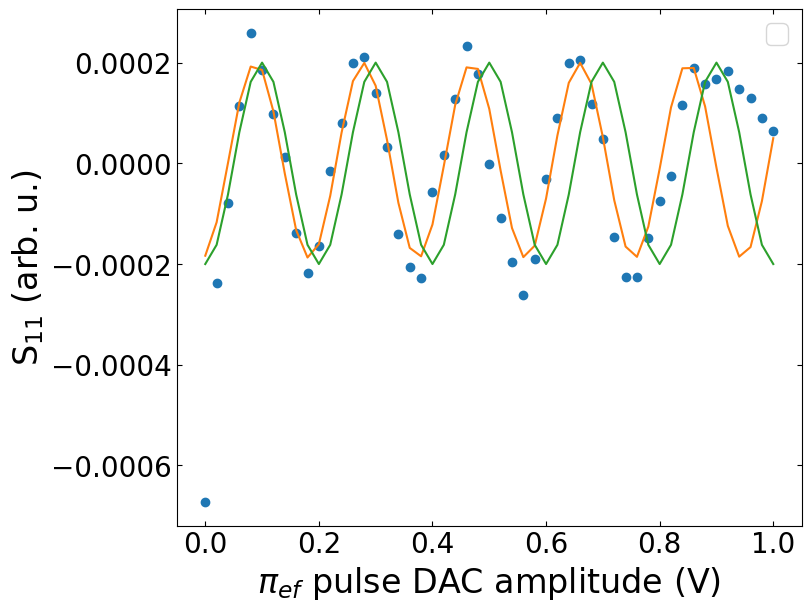

In [37]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_ef.plot_fit(ax = ax)
plt.plot(amp_ef,result_ef.init_fit)

plt.title("")
plt.legend("")
ax.set_xlabel('$\pi_{ef}$ pulse DAC amplitude (V)', size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)', size='large')
# # ax.set_ylim(-40, 40)
# ax.set_xlim(0, 1.)
# plt.savefig('ef_rabi.png', bbox_inches='tight')
plt.show()

In [38]:
np.pi/(5.25071238*2*np.pi)*5

0.47612586999099726

ramsey

In [90]:
pl = "/2025-02-19/2025-02-19T233601_d72194fc-d2_ef_T2r1d"
mi = "/2025-02-19/2025-02-19T233638_ed800518-d2_ef_T2r1d"
dd_pl = datadict_from_hdf5(header + pl +"/data")
dd_mi = datadict_from_hdf5(header + mi +"/data")

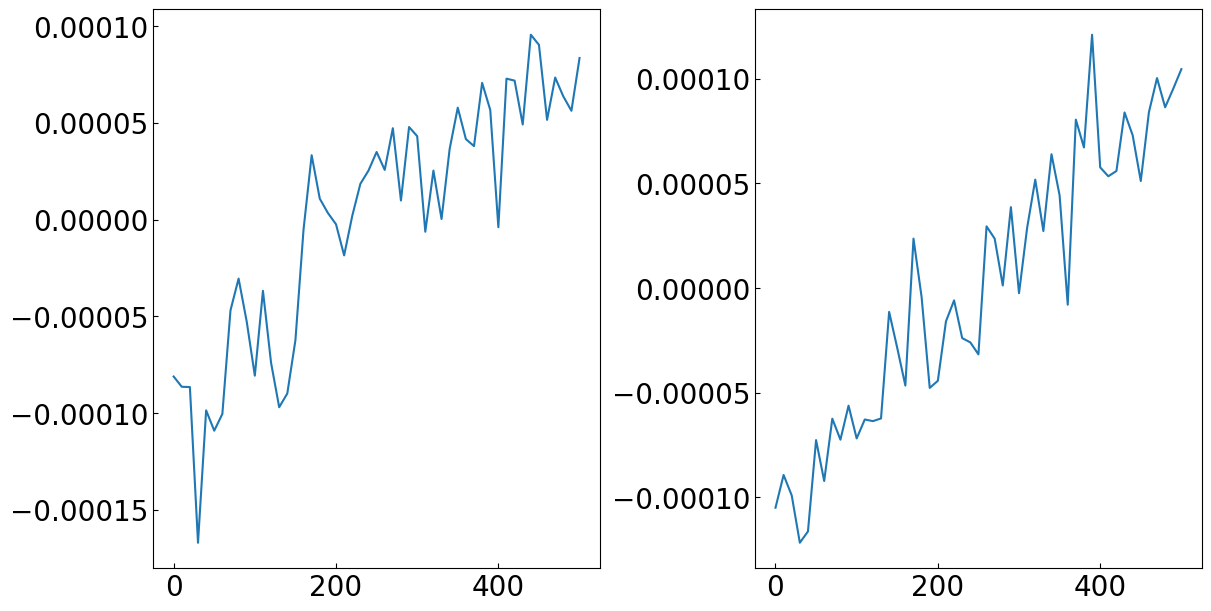

In [91]:
Rabi_pl = dd_pl['s11']['values']
delay_pl = dd_pl['delay']['values']
Rabi_mi = dd_mi['s11']['values']
delay_mi = dd_mi['delay']['values']

I_pl = (Rabi_pl.real)
Q_pl = (Rabi_pl.imag)
I_mi = (Rabi_mi.real)
Q_mi = (Rabi_mi.imag)

PCA_pl = PCA_transform(I_pl, Q_pl)
y_pl = PCA_pl[0]
x_pl = delay_pl

PCA_mi = PCA_transform(I_mi, Q_mi)
y_mi = PCA_mi[0]
x_mi = delay_mi

fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
ax[0].plot(x_pl, y_pl)
ax[1].plot(x_mi, y_mi)
plt.show()

In [28]:
par_ini_pl = {'amp': 0.0002,'phi0':0,'detun':1/200,'const':0.00001}
par_ini_mi = {'amp': 0.0002,'phi0':0,'detun':1/200,'const':0.00001}
par_min = {'amp': 0,'phi0':-2*np.pi,'detun':-np.inf,'const':0}
par_max = {'amp': np.inf,'phi0':2*np.pi,'detun':np.inf,'const':np.inf,}
par_vary = {'amp': True,'phi0':True,'detun':True,'const':True}

model = lmfit.Model(Rabi)

In [29]:
params_pl = model.make_params()
for name in model.param_names:
    params_pl[name].set(value = par_ini_pl[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
    
result_pl = model.fit(data = y_pl, params = params_pl, delay = x_pl)
result_pl


In [30]:
params_mi = model.make_params()
for name in model.param_names:
    params_mi[name].set(value = par_ini_mi[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
    
result_mi = model.fit(data = y_mi, params = params_mi, delay = x_mi)
result_mi

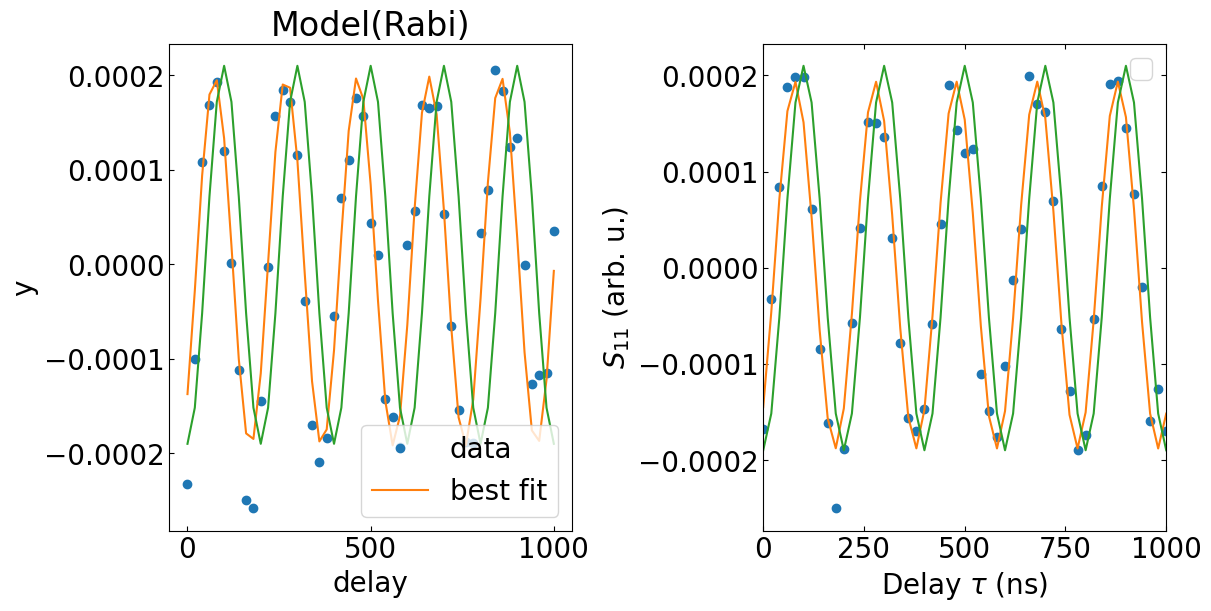

In [31]:
fig, ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_pl.plot_fit(ax = ax[0])
ax[0].plot(x_pl,result_pl.init_fit)
result_mi.plot_fit(ax = ax[1])
ax[1].plot(x_mi,result_mi.init_fit)

plt.title("")
plt.legend("")
plt.xlabel(r"Delay ${\tau}$ (ns)")
plt.ylabel("$S_{11}$ (arb. u.)")
plt.xlim(0, 1000)
# plt.savefig('ef_ramsey_exp.png', bbox_inches='tight')
plt.show()

In [32]:
detun = ((0.005-0.00511954)+ (	0.00499076-0.005))/2 #GHz
detun

-6.438999999999967e-05

drag

In [39]:
drag = "/2025-02-17/2025-02-17T161317_a902974d-d1_ef_pi_drag" #n=7
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2025-02-17/2025-02-17T161359_c22151ac-d1_ef_pi_drag" #n=11
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2025-02-17/2025-02-17T161441_db59b8c5-d1_ef_pi_drag" #n=17
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [40]:
Rabi_drag = dd_drag['s11']['values']
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [41]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

In [42]:
PCA_drag = PCA_transform1(I_drag, Q_drag, I_drag, Q_drag)
y = PCA_drag[0]
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_drag, Q_drag, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_drag, Q_drag, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2

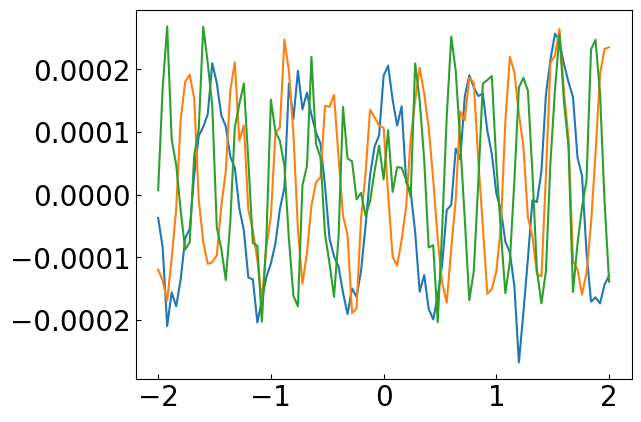

In [43]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [54]:
par_ini= {'amp': 0.0002,'phi0':np.pi,'detun':1/0.3,'const':0}
par_min = {'amp': 0,'phi0':-2*np.pi,'detun':-np.inf,'const':-np.pi}
par_max = {'amp': np.inf,'phi0':2*np.pi,'detun':np.inf,'const':np.inf,}
par_vary = {'amp': True,'phi0':True,'detun':True,'const':True}
model = lmfit.Model(Rabi)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

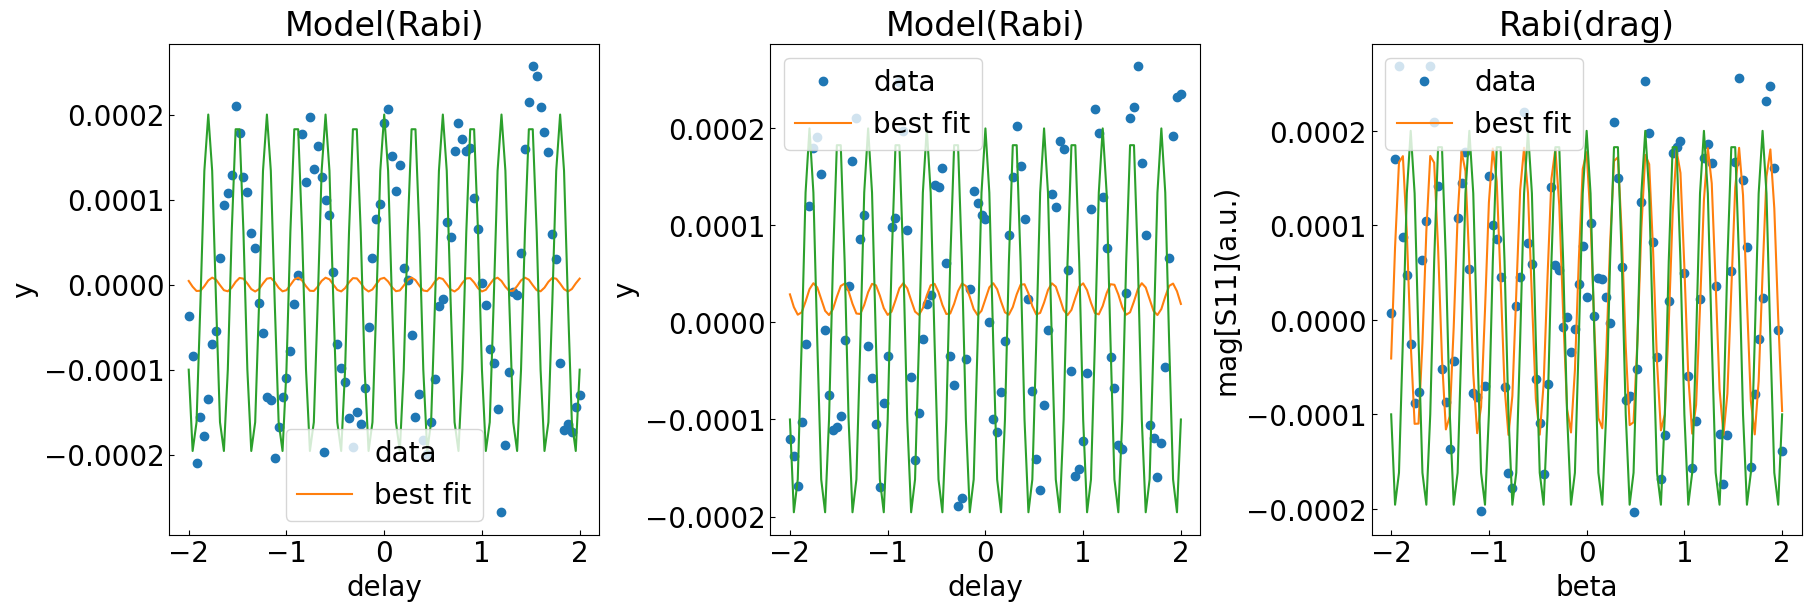

In [55]:
fig, ax = plt.subplots(1,3,figsize=(18,6),constrained_layout=True)
plt.title("Rabi(drag)")
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax[0])
ax[0].plot(x0,result0.init_fit)
result1.plot_fit(ax = ax[1])
ax[1].plot(x1,result1.init_fit)
result2.plot_fit(ax = ax[2])
ax[2].plot(x2,result2.init_fit)
plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")
plt.show()

In [46]:
result0

In [47]:
res0 = (-2*np.pi-2.80839921)/(2*np.pi*1.31290990)
res0

-1.1021096089281328

In [50]:
result1

In [51]:
res1 = (-4*np.pi-4.36173387)/(2*np.pi*	2.43870219)
res1

-1.1047644591084091

In [56]:
result2

In [58]:
res2 = (-6*np.pi-3.3905197)/(2*np.pi*3.18348985)
res2

-1.1118672075883798

In [59]:
beta = (res0 + res1 + res2)/3
beta

-1.1062470918749738

half drag

In [60]:
drag = "/2025-02-17/2025-02-17T161848_6ea33175-d1_ef_half_pi_drag" #n=7
dd_drag = datadict_from_hdf5(header + drag +"/data")

drag1 = "/2025-02-17/2025-02-17T161930_87611ed1-d1_ef_half_pi_drag" #n=13
dd_drag1 = datadict_from_hdf5(header + drag1 +"/data")

drag2 = "/2025-02-17/2025-02-17T162033_ad0dc150-d1_ef_half_pi_drag" #n=17
dd_drag2 = datadict_from_hdf5(header + drag2 +"/data")

In [61]:
Rabi_drag = dd_drag['s11']['values']
drag = dd_drag['beta']['values']
I_drag = (Rabi_drag.real)
Q_drag = (Rabi_drag.imag)

Rabi_drag1 = dd_drag1['s11']['values']
drag1 = dd_drag1['beta']['values']
I_drag1 = (Rabi_drag1.real)
Q_drag1 = (Rabi_drag1.imag)

Rabi_drag2 = dd_drag2['s11']['values']
drag2 = dd_drag2['beta']['values']
I_drag2 = (Rabi_drag2.real)
Q_drag2 = (Rabi_drag2.imag)

In [62]:
PCA_drag = PCA_transform1(I_drag, Q_drag, I_drag, Q_drag)
y = PCA_drag[0]
y0 = PCA_drag[2]
x0 = drag

PCA_drag1 = PCA_transform1(I_drag, Q_drag, I_drag1, Q_drag1)
y1 = PCA_drag1[2]
x1 = drag1

PCA_drag2 = PCA_transform1(I_drag, Q_drag, I_drag2, Q_drag2)
y2 = PCA_drag2[2]
x2 = drag2

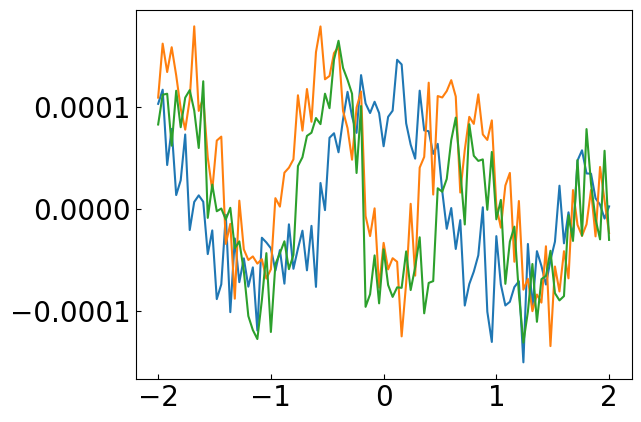

In [63]:
plt.plot(x0, y0)
plt.plot(x1, y1)
plt.plot(x2, y2)
plt.show()

In [69]:
par_ini= {'amp': 0.0001,'phi0':0,'detun':1/1,'const':0}
par_min = {'amp': 0,'phi0':-2*np.pi,'detun':-np.inf,'const':-np.pi}
par_max = {'amp': np.inf,'phi0':2*np.pi,'detun':np.inf,'const':np.inf,}
par_vary = {'amp': True,'phi0':True,'detun':True,'const':True}
model = lmfit.Model(Rabi)

model = lmfit.Model(Rabi)
params = model.make_params()
for name in model.param_names:
    params[name].set(value = par_ini[name],min = par_min[name],max = par_max[name],vary = par_vary[name])
    
result0 = model.fit(data = y0, params = params, delay = x0)
result1 = model.fit(data = y1, params = params, delay = x1)
result2 = model.fit(data = y2, params = params, delay = x2)

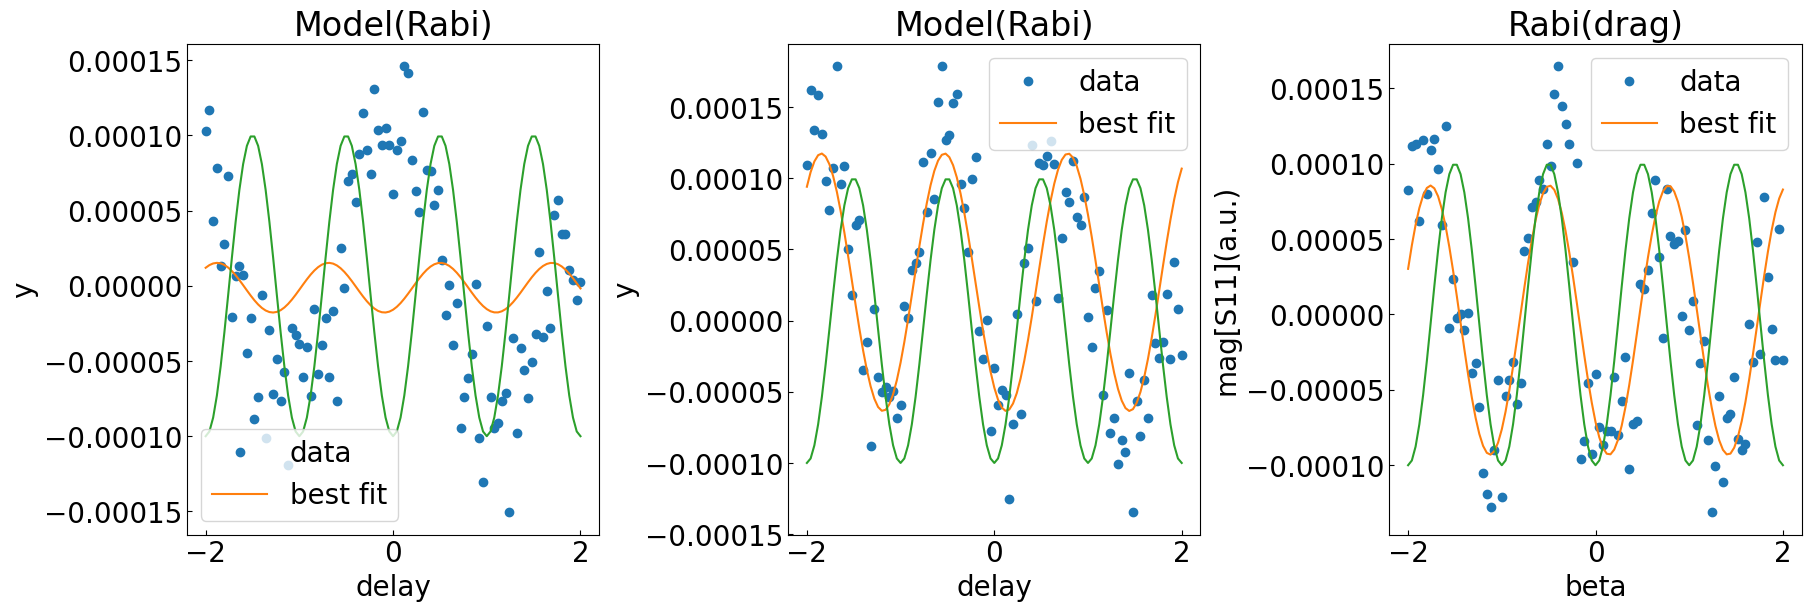

In [70]:
fig, ax = plt.subplots(1,3,figsize=(18,6),constrained_layout=True)
plt.title("Rabi(drag)")
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result0.plot_fit(ax = ax[0])
ax[0].plot(x0,result0.init_fit)
result1.plot_fit(ax = ax[1])
ax[1].plot(x1,result1.init_fit)
result2.plot_fit(ax = ax[2])
ax[2].plot(x2,result2.init_fit)
plt.xlabel("beta")
plt.ylabel("mag[S11](a.u.)")
plt.show()

In [66]:
result0

In [67]:
res0 = (-3.11945392)/(2*np.pi*0.43555696)
res0

-1.1398658653402989

In [71]:
result1

In [73]:
res1 = (0.61253757-2*np.pi)/(2*np.pi*0.75975237)
res1

-1.1879023396860247

In [74]:
result2

In [75]:
res2 = (0.71268372-2*np.pi)/(2*np.pi*0.78718436)
res2

-1.126258228886661

In [76]:
(res0+res1+res2)/3

-1.1513421446376615

T1

In [77]:
def Dephase(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

t1 ="/2025-02-17/2025-02-17T162410_2e70ac48-d3_ef_T1"

dd_t1 = datadict_from_hdf5(header + t1 +"/data")

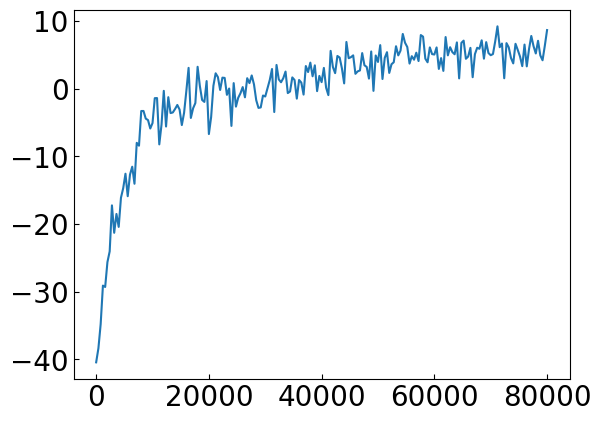

In [78]:
s11_t1 = dd_t1['s11']['values']
delay_t1 = dd_t1['delay']['values']
I_t1 = (s11_t1.real)
Q_t1 = (s11_t1.imag)
PCA_t1 = PCA_transform(I_t1, Q_t1)

y_t1 = PCA_t1[0]
x_t1 = delay_t1

plt.plot(x_t1, y_t1)
plt.show()

In [79]:
par_ini_t1 = {'gamma': 1/40000e-3,'amp':1,'const':-2.4}
par_min_t1 = {'gamma': 0,'amp':0,'const':-np.inf}
par_max_t1 = {'gamma': np.inf,'amp':np.inf,'const':np.inf,}
par_vary_t1 = {'gamma': True,'amp':True,'const':True}

model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t1[name],
    min = par_min_t1[name],
    max = par_max_t1[name],
    vary = par_vary_t1[name]
    )
result_t1 = model.fit(data = -y_t1, params = params, delay = x_t1*1e-3)
result_t1

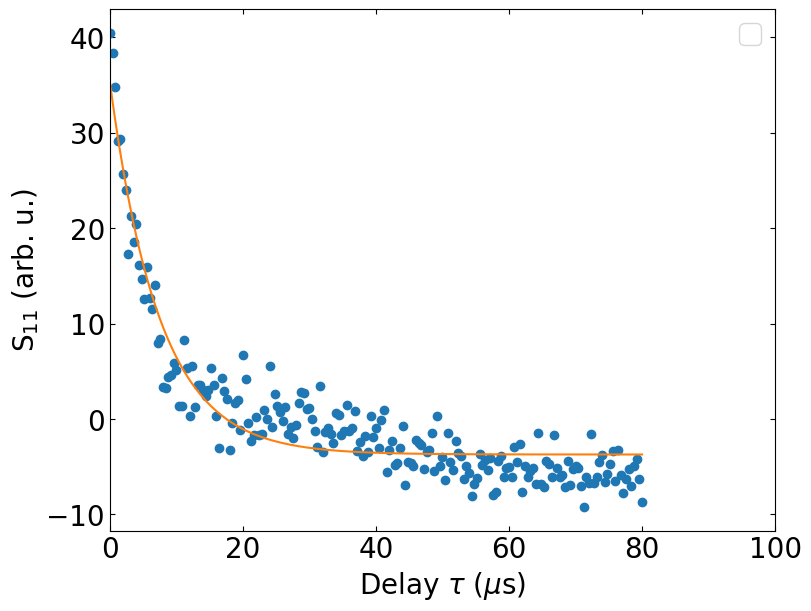

In [80]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20

plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result_t1.plot_fit(ax = ax)
# plt.plot(delay_t1,result_t1.init_fit)

plt.title("")
plt.legend("")
ax.set_xlabel(r'Delay $\tau$ ($\mu$s)')#, size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)')
ax.set_xlim(0, 100)
# plt.savefig('ef_T1.png', bbox_inches='tight')

plt.show()

In [81]:
T1 = (1/	0.13425801)*1e-9
T1

7.448345167636553e-09